### Basic Code Block Example

This cell contains a simple Python print statement.

In [1]:
print('Hello, Colab!')

Hello, Colab!


To execute this code block, you can click the "Run cell" button (a play icon) to the left of the cell, or select the cell and press `Shift + Enter`.

In [2]:
pip install pandas

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [4]:
!pip install prophet

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [9]:
df.dropna(inplace=True)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [12]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [13]:
df['Year'] = df['Order Date'].dt.year

df['Month'] = df['Order Date'].dt.month

df['Quarter'] = df['Order Date'].dt.quarter

In [14]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Quarter
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,4
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,4
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,4
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,4


In [15]:
monthly_sales = df.groupby(
    pd.Grouper(
        key='Order Date',
        freq='M'
    )
)['Sales'].sum().reset_index()

monthly_sales.head()

,Order Date,Sales
0,2014-01-31,14236.895
1,2014-02-28,4519.892
2,2014-03-31,55691.009
3,2014-04-30,28295.345
4,2014-05-31,23648.287


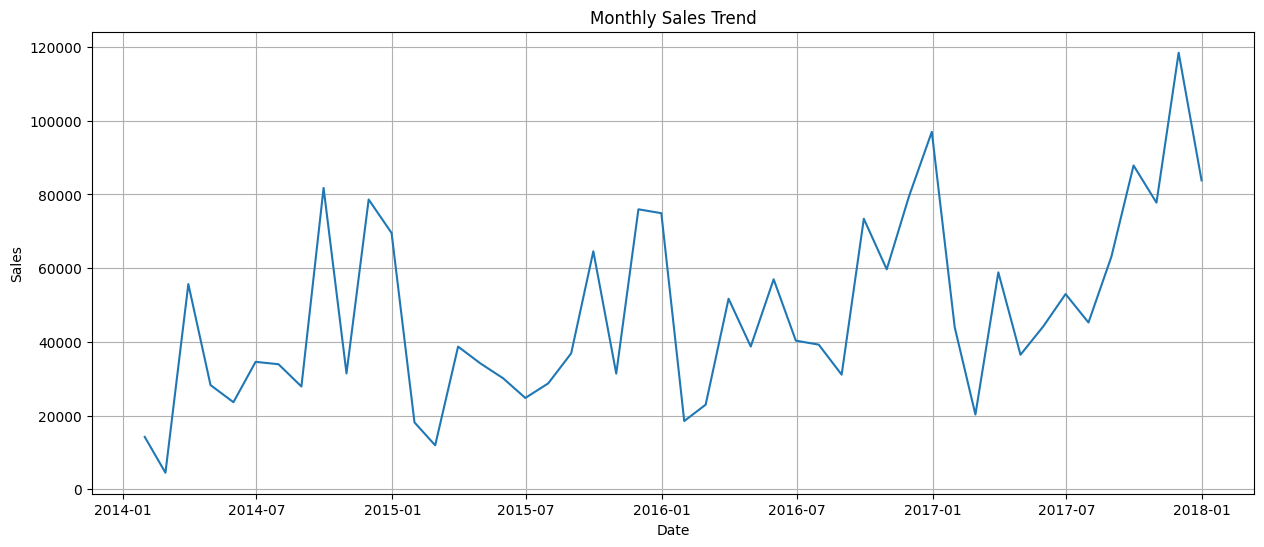

In [16]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales['Order Date'],
    monthly_sales['Sales']
)

plt.title("Monthly Sales Trend")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [17]:
prophet_df = monthly_sales.rename(columns={'Order Date': 'ds', 'Sales': 'y'})
prophet_df.head()

,ds,y
0,2014-01-31,14236.895
1,2014-02-28,4519.892
2,2014-03-31,55691.009
3,2014-04-30,28295.345
4,2014-05-31,23648.287


In [18]:
forecast_data = monthly_sales.rename(
    columns={
        'Order Date':'ds',
        'Sales':'y'
    }
)

forecast_data.head()

,ds,y
0,2014-01-31,14236.895
1,2014-02-28,4519.892
2,2014-03-31,55691.009
3,2014-04-30,28295.345
4,2014-05-31,23648.287


In [19]:
model = Prophet()

model.fit(forecast_data)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [20]:
future = model.make_future_dataframe(
    periods=12,
    freq='M'
)

In [21]:
forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2014-01-31,32303.414197,5881.516237,24312.055432,32303.414197,32303.414197,-17512.849991,-17512.849991,-17512.849991,-17512.849991,-17512.849991,-17512.849991,0.0,0.0,0.0,14790.564205
1,2014-02-28,32773.318433,-3041.616984,15025.503545,32773.318433,32773.318433,-26994.778966,-26994.778966,-26994.778966,-26994.778966,-26994.778966,-26994.778966,0.0,0.0,0.0,5778.539467
2,2014-03-31,33293.569551,32631.105243,50978.054762,33293.569551,33293.569551,8581.774390,8581.774390,8581.774390,8581.774390,8581.774390,8581.774390,0.0,0.0,0.0,41875.343941
3,2014-04-30,33797.038374,15989.246512,34643.082719,33797.038374,33797.038374,-8134.314348,-8134.314348,-8134.314348,-8134.314348,-8134.314348,-8134.314348,0.0,0.0,0.0,25662.724026
4,2014-05-31,34317.289488,16798.377561,35901.955082,34317.289488,34317.289488,-8605.361273,-8605.361273,-8605.361273,-8605.361273,-8605.361273,-8605.361273,0.0,0.0,0.0,25711.928216


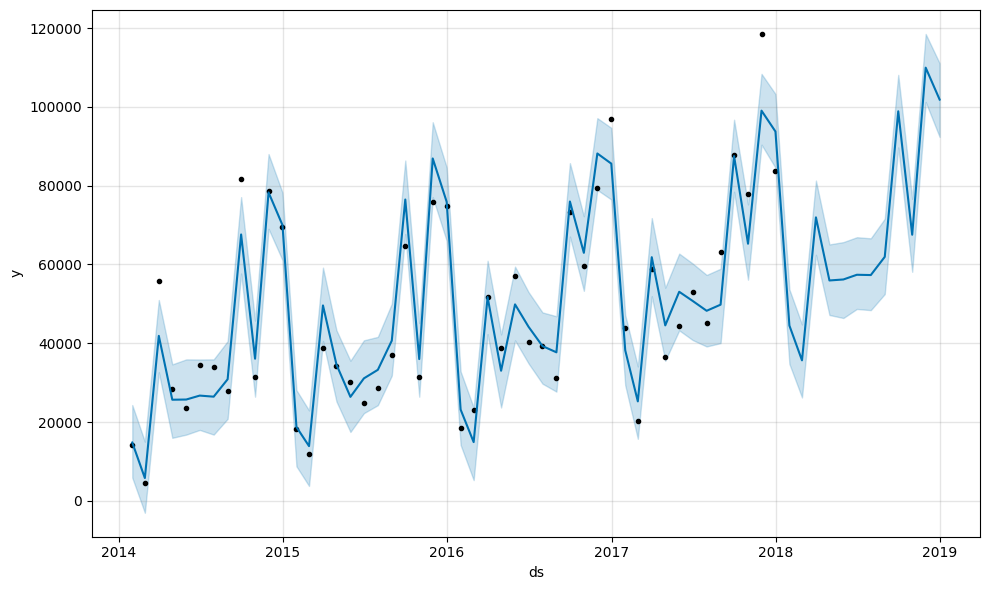

In [22]:
model.plot(forecast)

plt.show()

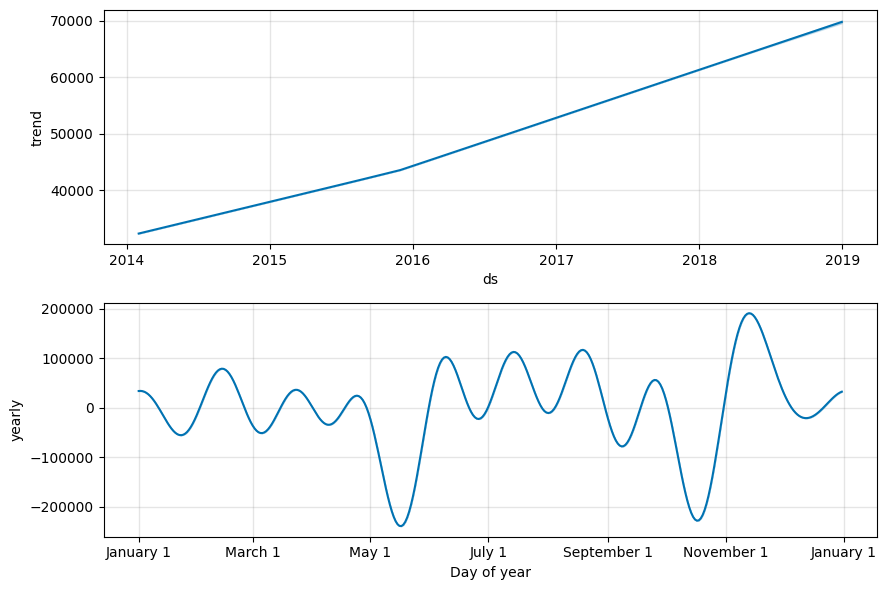

In [23]:
model.plot_components(forecast)

plt.show()

In [24]:
future_forecast = forecast[
    ['ds','yhat','yhat_lower','yhat_upper']
]

future_forecast.tail(12)

,ds,yhat,yhat_lower,yhat_upper
48,2018-01-31,44491.081303,34753.451317,53646.118847
49,2018-02-28,35661.189749,26231.526477,44776.187831
50,2018-03-31,71959.641678,62454.638794,81305.665815
51,2018-04-30,55942.164463,47173.374648,65092.875837
52,2018-05-31,56193.016112,46407.736297,65679.973374
53,2018-06-30,57387.967880,48707.431350,66921.753959
54,2018-07-31,57316.011968,48406.769961,66644.024383
55,2018-08-31,61936.117123,52489.593728,71614.184413
56,2018-09-30,98895.786376,89723.737070,108140.417575
57,2018-10-31,67553.702961,58138.983984,76657.984077


In [25]:
future_forecast.to_csv(
    "sales_forecast.csv",
    index=False
)

In [26]:
from google.colab import files

files.download(
    "sales_forecast.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
import pickle

pickle.dump(
    model,
    open(
        "sales_forecast_model.pkl",
        "wb"
    )
)

In [28]:
files.download(
    "sales_forecast_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
monthly_sales.to_csv(
    "monthly_sales.csv",
    index=False
)

In [30]:
files.download(
    "monthly_sales.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(12)

,ds,yhat,yhat_lower,yhat_upper
48,2018-01-31,44491.081303,34753.451317,53646.118847
49,2018-02-28,35661.189749,26231.526477,44776.187831
50,2018-03-31,71959.641678,62454.638794,81305.665815
51,2018-04-30,55942.164463,47173.374648,65092.875837
52,2018-05-31,56193.016112,46407.736297,65679.973374
53,2018-06-30,57387.967880,48707.431350,66921.753959
54,2018-07-31,57316.011968,48406.769961,66644.024383
55,2018-08-31,61936.117123,52489.593728,71614.184413
56,2018-09-30,98895.786376,89723.737070,108140.417575
57,2018-10-31,67553.702961,58138.983984,76657.984077


In [32]:
train = forecast_data[:-12]
test = forecast_data[-12:]

model = Prophet()
model.fit(train)

future = model.make_future_dataframe(periods=12, freq='M')
forecast = model.predict(future)

predictions = forecast[['ds','yhat']].tail(12)

actual = test['y'].values
predicted = predictions['yhat'].values

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

print("MAE:", mae)
print("RMSE:", rmse)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


MAE: 11648.9174057533
RMSE: 15252.54208218633
